### Huber Loss Explained Simply

Think of **Huber Loss** as the **best of both worlds**—it combines the strengths of **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)** while avoiding their weaknesses.

---

### 1. The Problem with MSE and MAE Alone

| Loss | What it does | Good for | Bad for |
| :--- | :--- | :--- | :--- |
| **MSE** | Squares the error $(y - y_{\text{pred}})^2$ | Small errors are treated gently. | Large errors become **huge** (squared), so a single outlier can dominate training. |
| **MAE** | Takes absolute value | $\text{mod}(y - y_{\text{pred}})$ | Treats all errors equally, robust to outliers. | Gradient is constant (not smaller near zero), making it hard to converge precisely. |

**Analogy:**  
- MSE is like a perfectionist: a small mistake is fine, but a big mistake feels catastrophic (outlier blows up loss).  
- MAE is like a patient teacher: every mistake gets same attention, so it doesn't panic over outliers, but it struggles to fine-tune when errors are already small.

---

### 2. The Huber Loss Formula

Huber Loss has a **switch** controlled by a parameter $\delta$ (delta):

$$
L_{\delta}(y, y_{\text{pred}}) = 
\begin{cases} 
\frac{1}{2} (y - y_{\text{pred}})^2 & \text{if } |y - y_{\text{pred}}| \le \delta \\
\delta |y - y_{\text{pred}}| - \frac{1}{2} \delta^2 & \text{otherwise}
\end{cases}
$$

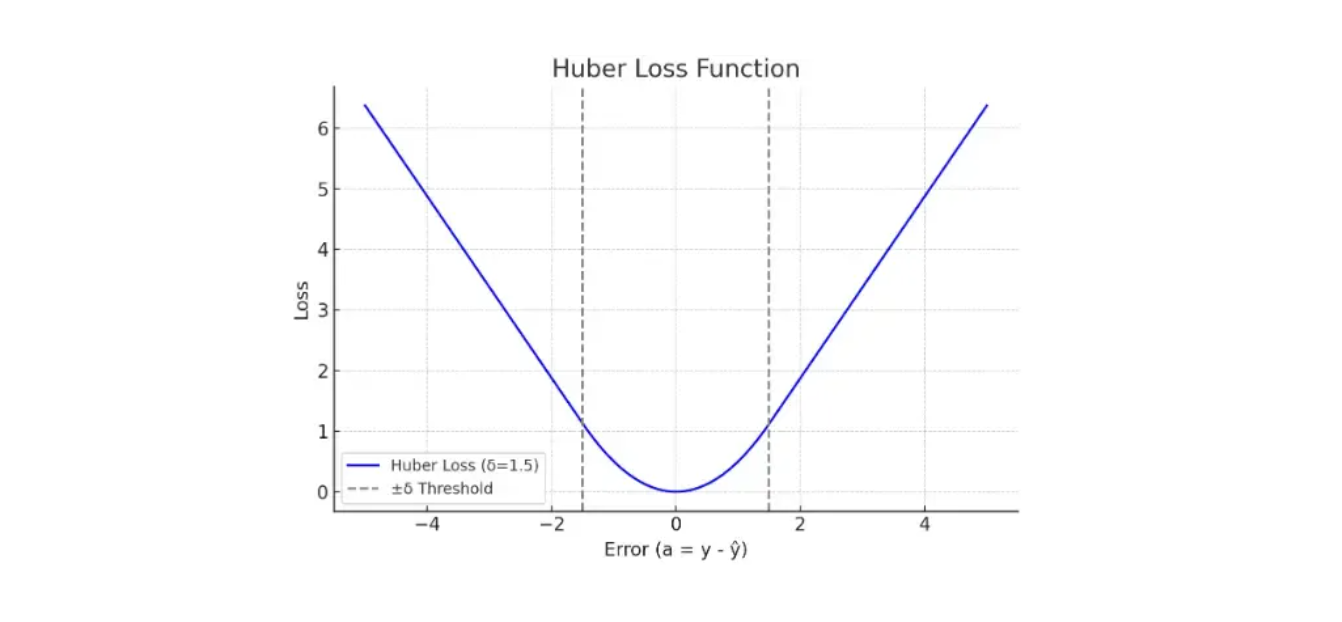

**In plain English:**  
- For **small errors** ($\le \delta$), use **MSE** (quadratic) → smooth and precise around zero.  
- For **large errors** ($> \delta$), use **MAE** (linear) → limits the influence of outliers.

---

### 3. Visual Comparison (Mental Picture)

Imagine a graph with **Error** on x-axis and **Loss** on y-axis:

- **MSE**: Curves upward parabolically → steep for large errors.
- **MAE**: V‑shape → constant slope, never flattens.
- **Huber**: Looks like MSE near zero, but becomes a straight line (like MAE) beyond $\pm\delta$.

**The “$\delta$” knob** lets you decide where to switch from quadratic to linear. Common choice: $\delta = 1.0$.

---

### 4. Why Use Huber Loss in Deep Learning?

| Property | MSE | MAE | **Huber** |
| :--- | :--- | :--- | :--- |
| Smooth at zero (gradient exists) | ✅ | ❌ (subgradient) | ✅ |
| Robust to outliers | ❌ | ✅ | ✅ (for large errors) |
| Differentiable everywhere | ✅ | ❌ (not at zero) | ✅ (if $\delta>0$) |
| Converges precisely when error small | ✅ | ❌ (constant gradient) | ✅ |

**Practical advantages:**
- **Outlier‑resistant**: A single bad prediction won't wreck the loss.
- **Stable training**: Avoids exploding gradients from squared large errors.
- **Fine‑tuning ability**: When predictions are already close, it behaves like MSE, giving small updates for fine adjustment.

---

### 5. When to Use Huber Loss Instead of MSE/MAE

| Scenario | Recommended Loss | Why |
| :--- | :--- | :--- |
| Data has **many outliers** (e.g., sensor noise, anomaly‑prone tasks) | **Huber or MAE** | MSE would over‑penalize outliers. |
| Need **smooth gradient** and **precision** near optimum | **Huber (or MSE)** | MAE's constant gradient can oscillate around minimum. |
| Simple baseline regression (clean data) | **MSE** | Easier, fast. |
| **Both outlier robustness and smooth convergence** | **Huber** | Best of both worlds. |
| Very deep networks / large gradients | **Huber** | Prevents gradient explosion from MSE outliers. |

---

### 6. Simple Example

Suppose true value = 0, and we have two predictions: $0.2$ (small error) and $10$ (large outlier).  
- **MSE**: $0.04$ for small, $100$ for outlier → outlier dominates.  
- **MAE**: $0.2$ and $10$ → outlier matters, but not overwhelmingly.  
- **Huber ($\delta=1$)**: small error → $0.02$ (MSE‑like). Outlier (error=10>$\delta$) → linear penalty $1 \cdot 10 - 0.5 = 9.5$. Less than MSE's 100, but still larger than MAE's 10.

You can tune $\delta$: smaller $\delta$ makes it behave more like MAE (more robust), larger $\delta$ makes it behave more like MSE (more sensitive to all errors).

---

### 7. Using Huber Loss in Code (TensorFlow/Keras)

```python
import tensorflow as tf

# Built‑in
model.compile(loss=tf.keras.losses.Huber(delta=1.0), optimizer='adam')

# Or custom
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = tf.abs(error)
    quadratic = 0.5 * tf.square(error)
    linear = delta * abs_error - 0.5 * delta**2
    return tf.where(abs_error <= delta, quadratic, linear)
```

---

### Summary

**Huber Loss = MSE for small errors + MAE for large errors**  
Use it when you want:  
- ✅ Robustness to outliers  
- ✅ Smooth optimization near the optimum  
- ✅ No need to choose between MSE and MAE

It's especially popular in **regression tasks** with noisy data, **reinforcement learning** (where rewards can be erratic), and any deep learning model where occasional large errors shouldn't destabilize training.

### Huber Loss: Gradient Descent & Parameter Updates

#### Overview

When training a neural network with **Huber Loss**, understanding how gradients flow through your parameters is key to appreciating why this loss function is so effective. Let's break down the math in an intuitive way.

---

#### 1. The Perceptron Model

Consider a simple linear regression neuron:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

Or more compactly:

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b$$

For any training sample with true value `y`, the **prediction error** is:

$$e = y - \hat{y}$$

This error is the foundation for computing loss and its gradients.

---

#### 2. Huber Loss Revisited

Huber Loss switches between two regimes based on a threshold parameter **δ** (delta):

$$L_\delta(e) = \begin{cases}
\frac{1}{2} e^2 & \text{if } |e| \le \delta \\[8pt]
\delta |e| - \frac{1}{2}\delta^2 & \text{if } |e| > \delta
\end{cases}$$

**Why the `-½δ²` term?**  
It ensures the loss function is **continuous** at the boundary `|e| = δ`, preventing sharp jumps in the loss landscape.

---

#### 3. The Gradient: ∂L/∂e

The derivative of Huber Loss with respect to the error tells us how sensitive the loss is to changes in the prediction:

$$\frac{\partial L}{\partial e} = \begin{cases}
e & \text{if } |e| \le \delta \\[8pt]
\delta \cdot \text{sign}(e) & \text{if } |e| > \delta
\end{cases}$$

Where `sign(e)` equals `+1` if `e > 0` and `-1` if `e < 0`.

**Interpretation:**
- **Small errors:** Gradient is proportional to error (like MSE) → precise fine-tuning
- **Large errors:** Gradient is capped at ±δ (like MAE) → prevents outlier explosions

---

#### 4. Chain Rule: From Error to Parameters

To find how the loss changes with respect to weights and bias, we apply the chain rule:

$$\frac{\partial L}{\partial \theta} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial \theta}$$

Since $e = y - ŷ$, we have:
- $∂e/∂w_j = -x_j$ (partial w.r.t. weight j)
- $∂e/∂b = -1$ (partial w.r.t. bias)

##### Gradient w.r.t. Weight w_j

$$\frac{\partial L}{\partial w_j} = \frac{\partial L}{\partial e} \cdot (-x_j)$$

Substituting the Huber gradient:

$$\frac{\partial L}{\partial w_j} = \begin{cases}
-e \cdot x_j & \text{if } |e| \le \delta \\[8pt]
-\delta \cdot \text{sign}(e) \cdot x_j & \text{if } |e| > \delta
\end{cases}$$

##### Gradient w.r.t. Bias b

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial e} \cdot (-1)$$

Which gives:

$$\frac{\partial L}{\partial b} = \begin{cases}
-e & \text{if } |e| \le \delta \\[8pt]
-\delta \cdot \text{sign}(e) & \text{if } |e| > \delta
\end{cases}$$

---

#### 5. Gradient Descent Parameter Update

During training, we move each parameter in the direction opposite the gradient (hence "descent"):

$$w_j \leftarrow w_j - \eta \cdot \frac{\partial L}{\partial w_j}$$

$$b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

Where **η** (eta) is the **learning rate**—a hyperparameter controlling step size.

---

#### 6. What These Updates Actually Mean

##### When Predictions Are Close: |e| ≤ δ

The gradient behaves like **MSE**:
- Error is small → gradient is small → tiny parameter update
- Error is moderate → gradient is moderate → reasonable update
- Convergence is **smooth and precise** near the optimum

**Benefit:** Fine-tuning works well; the model can make delicate adjustments.

##### When Predictions Are Very Wrong: |e| > δ

The gradient is **capped** at magnitude δ:
- Huge error → gradient still only ±δ → bounded update
- Outlier doesn't cause catastrophic parameter shifts
- Training remains **stable and robust**

**Benefit:** A single bad prediction won't destabilize the entire network.

---

#### 7. Visual Intuition: Gradient Landscape

| Scenario | MSE Gradient | MAE Gradient | Huber Gradient |
|----------|--------------|--------------|----------------|
| Small error (e = 0.1) | 0.1 | 1 (constant) | 0.1 |
| Medium error (e = 0.5) | 0.5 | 1 (constant) | 0.5 |
| Large error (e = 5, δ=1) | 5 | 1 (constant) | 1 (capped) |
| Huge outlier (e = 100, δ=1) | 100 | 1 (constant) | 1 (capped) |

**The Huber advantage:** Small errors get precise gradients (MSE-like), large errors get bounded gradients (MAE-like).

---

#### 8. Practical Example: Single Update Step

**Setup:**
- True value: `y = 5`
- Prediction: `ŷ = 3`
- Error: `e = 2`
- Learning rate: `η = 0.1`
- Delta: `δ = 1`
- Input feature: `x = 2`

**Since |e| = 2 > δ = 1, we're in the "outlier regime":**

$$\frac{\partial L}{\partial w} = -\delta \cdot \text{sign}(e) \cdot x = -1 \cdot (+1) \cdot 2 = -2$$

$$w_{\text{new}} = w_{\text{old}} - 0.1 \cdot (-2) = w_{\text{old}} + 0.2$$

The weight increases by `0.2` to reduce the error. Notice the gradient is bounded—if the error were 100 instead of 2, the gradient would still be `-2` (not `-200`), keeping updates stable.

---

#### 9. Summary: Why Huber Gradients Matter

| Property | Impact |
|----------|--------|
| **Smooth near zero** | Gradients exist everywhere; no dead zones like MAE |
| **Bounded for outliers** | Large errors don't cause exploding gradients |
| **Adaptive behavior** | Acts like MSE when precise, MAE when robust |
| **Training stability** | Fewer divergences; faster convergence |
| **Tunable via δ** | Adjust robustness by changing the threshold |

**Bottom line:** Huber Loss gives you a gradient that is **precise when it matters** (small errors) and **protective when it matters** (large outliers). This is why it's a favorite in production machine learning.

<br>

---

<br>

### Derivation of Backpropagation for Multiclass Classification

This document details the step-by-step derivation of the backpropagation equations for a neural network layer performing multiclass classification. We assume a standard setup using Softmax activation and Categorical Cross-Entropy Loss.

1. Notation and Setup

Let's define our variables for a single training example with $N$ classes.

$x$: Input vector of shape $(D \times 1)$, where $D$ is the number of input features.

$W$: Weight matrix of shape $(N \times D)$.

$b$: Bias vector of shape $(N \times 1)$.

$z$: The "logits" or linear output, shape $(N \times 1)$.

$a$: The activation (predicted probabilities) output by Softmax, shape $(N \times 1)$.

$y$: The ground truth label (one-hot encoded vector), shape $(N \times 1)$.

The Forward Pass Equations

Linear Transformation:


$$z_i = \sum_{d=1}^{D} W_{id} x_d + b_i$$


In vector form: $z = Wx + b$

Softmax Activation:


$$a_i = \frac{e^{z_i}}{\sum_{k=1}^{N} e^{z_k}}$$


Note: $a_i$ is often denoted as $\hat{y}_i$.

Categorical Cross-Entropy Loss:


$$L = -\sum_{k=1}^{N} y_k \log(a_k)$$


Since $y$ is a one-hot vector (only one element is 1, the rest are 0), if the true class is $c$, this simplifies to $L = -\log(a_c)$. However, we will use the summation form for the general derivation.

2. The Goal

To update the weights and biases using gradient descent, we need to find the partial derivatives of the Loss $L$ with respect to the weights $W$ and biases $b$:

$$\frac{\partial L}{\partial W} \quad \text{and} \quad \frac{\partial L}{\partial b}$$

Using the Chain Rule, we can break this down:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial W}$$

We will compute this layer by layer, starting from the loss and moving backward.

3. Step-by-Step Derivation

Step A: Derivative of Loss w.r.t. Softmax Output ($a$)

First, we differentiate the loss function $L$ with respect to the $k$-th output activation $a_k$.

$$L = -\sum_{n=1}^{N} y_n \log(a_n)$$

Focusing on a specific class index $k$:

$$\frac{\partial L}{\partial a_k} = -\frac{\partial}{\partial a_k} \left( y_k \log(a_k) + \sum_{n \neq k} y_n \log(a_n) \right)$$

Since the terms where $n \neq k$ are constant with respect to $a_k$:

$$\boxed{\frac{\partial L}{\partial a_k} = -\frac{y_k}{a_k}}$$

Step B: Derivative of Softmax ($a$) w.r.t. Logits ($z$)

This is the trickiest part. The Softmax function relates every output $a_k$ to every input $z_j$ because of the denominator sum.

$$a_k = \frac{e^{z_k}}{\Sigma} \quad \text{where} \quad \Sigma = \sum_{n=1}^{N} e^{z_n}$$

We need to find $\frac{\partial a_k}{\partial z_j}$. There are two cases to consider using the quotient rule: $\left( \frac{u}{v} \right)' = \frac{u'v - uv'}{v^2}$.

Case 1: $k = j$
We are differentiating the output $a_j$ with respect to its own specific input $z_j$.


$$\frac{\partial a_j}{\partial z_j} = \frac{(e^{z_j})(\Sigma) - (e^{z_j})(e^{z_j})}{\Sigma^2}$$

$$= \frac{e^{z_j}}{\Sigma} \cdot \frac{\Sigma - e^{z_j}}{\Sigma} = a_j (1 - a_j)$$

Case 2: $k \neq j$
We are differentiating an output $a_k$ with respect to a different input $z_j$. The numerator $e^{z_k}$ is constant w.r.t $z_j$.


$$\frac{\partial a_k}{\partial z_j} = \frac{(0)(\Sigma) - (e^{z_k})(e^{z_j})}{\Sigma^2}$$

$$= -\frac{e^{z_k}}{\Sigma} \cdot \frac{e^{z_j}}{\Sigma} = -a_k a_j$$

Summary of Step B:


$$\frac{\partial a_k}{\partial z_j} = \begin{cases} a_j(1 - a_j) & \text{if } k=j \\ -a_k a_j & \text{if } k \neq j \end{cases}$$


This can be written using the Kronecker delta $\delta_{kj}$ (which is 1 if $k=j$ and 0 otherwise):


$$\boxed{\frac{\partial a_k}{\partial z_j} = a_k (\delta_{kj} - a_j)}$$

Step C: Derivative of Loss ($L$) w.r.t. Logits ($z$)

Now we combine Step A and Step B using the Chain Rule. We want the sensitivity of the Loss to a specific logit $z_j$. Since $z_j$ affects the Loss through all $N$ Softmax outputs, we must sum gradients from all $a_k$.

$$\frac{\partial L}{\partial z_j} = \sum_{k=1}^{N} \frac{\partial L}{\partial a_k} \cdot \frac{\partial a_k}{\partial z_j}$$

Substitute the results from Steps A and B:

$$\frac{\partial L}{\partial z_j} = \sum_{k=1}^{N} \left( -\frac{y_k}{a_k} \right) \cdot (a_k (\delta_{kj} - a_j))$$

Simplify the term inside the sum:

$$\frac{\partial L}{\partial z_j} = -\sum_{k=1}^{N} y_k (\delta_{kj} - a_j)$$

$$\frac{\partial L}{\partial z_j} = -\left( \sum_{k=1}^{N} y_k \delta_{kj} - \sum_{k=1}^{N} y_k a_j \right)$$

Let's analyze the two summation terms:

$\sum_{k=1}^{N} y_k \delta_{kj}$: Since $\delta_{kj}$ is 0 except when $k=j$, this sum collapses to simply $y_j$.

$\sum_{k=1}^{N} y_k a_j$: $a_j$ is constant w.r.t the sum index $k$, so we pull it out: $a_j \sum_{k=1}^{N} y_k$. Since $y$ is a one-hot vector (probabilities sum to 1), $\sum y_k = 1$. Thus, this term is $a_j$.

Putting it back together:


$$\frac{\partial L}{\partial z_j} = -(y_j - a_j)$$

$$\boxed{\frac{\partial L}{\partial z_j} = a_j - y_j}$$

This beautiful, simple result is why Softmax is nearly always paired with Cross-Entropy. The error signal is simply the difference between the predicted probability and the true label.

<br>

---

<br>

### Interpreting Loss Values in Machine Learning

Think of loss as **a score that tells you "how wrong" your model is**. **Lower is better**, and zero implies a perfect prediction. However, whether a loss value is "huge" depends entirely on the context of your specific problem.

---

### 1. Regression Loss Functions

#### Common Loss Functions
1. Mean Absolute Error (MAE / L1 Loss)
2. Mean Squared Error (MSE / L2 Loss)
3. Root Mean Squared Error (RMSE)
4. Mean Absolute Percentage Error (MAPE)

---

#### Mean Absolute Error (MAE)

$$ \text{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|y_i-\hat{y}_i\right| $$

*   **Interpretation:** "On average, how far off is each prediction in the original units."
*   **Example:** If predicting house prices with `MAE = $25,000`, it means predictions are off by $25,000 on average.
*   **Is $25,000 huge?** It depends:
    *   If average house price = $500,000 → **5% error** → **Reasonable**
    *   If average house price = $100,000 → **25% error** → **Huge**

> **Tip:** To interpret MSE, first calculate the **RMSE** (square root), then calculate the **MAPE** to compare against a percentage baseline.

---

#### Root Mean Squared Error (RMSE)

$$ \text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(y_i-\hat{y}_i\right)^2} $$

RMSE converts the squared error back to the original unit of the target variable, making it much easier to interpret than MSE.

---

#### Mean Absolute Percentage Error (MAPE)

$$ \text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i-\hat{y}_i}{y_i} \right| \% $$

*   **Interpretation:** Average percentage error between predicted and actual values.
*   **Unit:** Percentage (%).
*   **Advantage:** Easy to interpret because it is **scale-independent**.

##### Rule of Thumb for MAPE
*   **MAPE < 5%** → Excellent performance
*   **5% ≤ MAPE < 10%** → Good performance
*   **10% ≤ MAPE < 20%** → Reasonable performance
*   **MAPE ≥ 20%** → Poor performance (highly dependent on the specific application)

> **Note:** MAPE should **not** be used when actual target values can be zero, as the denominator becomes zero.

---

#### Mean Squared Error (MSE)

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left(y_i-\hat{y}_i\right)^2 $$

*   **Interpretation:** "Average of squared errors." It penalizes large errors more heavily than MAE.
*   **The Tricky Part:** Units are squared (e.g., dollars², meters²), making them difficult to interpret directly.

**Example Calculation:**
If `MSE = 6,250,000`:

$$ \text{RMSE} = \sqrt{6,250,000} = 2,500 $$

So, the model's average prediction error is about **$2,500**, which may actually be small for high-value house prices.

---

#### Rule of Thumb for Regression

Always compare the loss to the **target variable's scale**.

*   **Good:** Loss < **5–10%** of the target range.
*   **Bad:** Loss > **20–30%** of the target range.

**Compare against the Standard Deviation:**
If the loss is greater than the standard deviation of the target variable ($\sigma_y$), your model may perform worse than simply predicting the mean.

$$ \text{Loss} > \sigma_y \implies \text{Model may be worse than a mean predictor} $$

Use the **$R^2$-score** to formally compare against the mean prediction baseline.

---

### 2. Classification Loss Functions

#### Common Loss Functions
1. Binary Cross-Entropy (Log Loss)
2. Categorical Cross-Entropy
3. Hinge Loss (SVM)

---

#### Binary Cross-Entropy (Log Loss)

$$ L = -\left[ y\log(p) + (1-y)\log(1-p) \right] $$

Where:
*   $y$ = true label (0 or 1)
*   $p$ = predicted probability of class 1

**Range:** $0 \le L < \infty$ (practically around 0 to 10)
*   **Perfect prediction:** $L = 0$
*   **Completely wrong prediction:** $L \rightarrow \infty$

##### Key Reference Points

**Random guessing (50% confidence):**
$$ L = -\log(0.5) = \log(2) \approx 0.693 $$

*   **Excellent model:** $L < 0.1$
*   **Pretty good model:** $L < 0.2$
*   **Poor model:** $L > 0.5$
*   **Very bad model:** $L > 1.0$

**Example Interpretation (Spam Detection):**
*   Model A: Loss = 0.05 → **Excellent**
*   Model B: Loss = 0.15 → **Good**
*   Model C: Loss = 0.40 → **Okay**
*   Model D: Loss = 1.20 → **Bad**
*   Model E: Loss = 0.693 → **Equivalent to random guessing**

---

#### Categorical Cross-Entropy (Multi-Class)

$$ L = -\sum_{i=1}^{C} y_i \log(p_i) $$

Where:
*   $C$ = number of classes
*   $y_i$ = true label (one-hot encoded)
*   $p_i$ = predicted probability for class $i$

##### Random Guessing Baseline

For $C$ equally likely classes, the loss for random guessing is:

$$ L = -\log\left(\frac{1}{C}\right) = \log(C) $$

**Examples:**
*   $C=2$ (Binary): $\log(2) \approx 0.693$
*   $C=3$ (Three classes): $\log(3) \approx 1.099$
*   $C=10$ (Ten classes): $\log(10) \approx 2.303$

A good model should achieve a loss **well below** the random guessing baseline.

---

### 3. Universal Framework to Assess "Hugeness"

For any problem, compare your model's loss against simple baselines. Ask:

1.  What is the loss if we always predict the **mean**?
2.  What is the loss if we predict the **mode**?
3.  What is the loss if we predict **randomly**?
4.  What is the loss using a **simple rule**?

Your model should outperform all of these baselines to be considered useful.

---

### 4. The Most Important Principle: Relative, Not Absolute

Absolute loss values have little meaning without context.

#### Wrong Thinking
"My model has loss **1.5**. Is that huge?"

#### Right Thinking
*   Baseline (predicting mean): Loss = 2.0
*   Simple linear model: Loss = 1.8
*   Complex model: Loss = 1.5

The complex model improves the baseline by:

$$ \frac{2.0 - 1.5}{2.0} \times 100 = 25\% $$

This is a meaningful improvement.

**Business Impact Example:**
*   Current production log loss = 0.30
*   Every increase of 0.10 in loss costs $10,000/month in churn.
*   Reducing the loss to 0.20 saves **$10,000/month**.

> **Remember:** A loss of **1,000** could be excellent (predicting planetary orbits in kilometers) or terrible (predicting exam scores out of 100). **Context is everything.**

---

### Loss Function vs. Cost Function

In Artificial Intelligence and Machine Learning, the terms **loss function** and **cost function** are often used interchangeably, but there is a technical distinction.

#### 1. Loss Function (Individual Error)
The **Loss Function** computes the error for a **single** training example.

Mathematically:
$$ L(\hat{y}, y) $$

Where:
*   $\hat{y}$ = predicted value
*   $y$ = true value

Its purpose is to measure how well the model performed on **one** data point.

#### 2. Cost Function (Average Error)
The **Cost Function** is the average of all individual losses over a dataset (or mini-batch).

$$ J(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} L(\hat{y}^{(i)}, y^{(i)}) $$

Where:
*   $\mathbf{w}$ = model weights
*   $b$ = bias
*   $n$ = number of training examples

Optimization algorithms such as **Gradient Descent** minimize the **cost function**.

#### Quick Comparison

| Feature | Loss Function | Cost Function |
| :--- | :--- | :--- |
| **Scope** | Single data point | Entire dataset or mini-batch |
| **Mathematical Form** | $L(\hat{y}, y)$ | $J(\mathbf{w}, b) = \frac{1}{n}\sum L(\hat{y}^{(i)}, y^{(i)})$ |
| **Purpose** | Measures error for one prediction | Measures average error of the model |
| **Optimization** | Not minimized directly | Minimized by Gradient Descent |